# Question 9: Create Congestion Indices Combining Multiple Variables

# Step 1 - Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 2 - Load Dataset

In [2]:
df = pd.read_csv("traffic_data_for_datascience.csv")

# Step 3 - Check Required Columns

In [3]:
print(df.columns)

Index(['Sensor_ID', 'Timestamp', 'Date', 'Day_Name', 'Month', 'Hour',
       'Is_Weekend', 'Peak_Period', 'Location', 'Road_Segment', 'Segment_Type',
       'Vehicle_Type', 'Weather', 'Weather_Severity', 'Traffic_Volume',
       'Avg_Speed_kmph', 'Congestion_Ratio', 'Congestion_Level',
       'Severity_Score', 'Hour_Time', 'Hour_Label', 'id'],
      dtype='object')


# Step 4 - Normalize Variables

# Normalize Traffic Volume

In [4]:
df['Normalized_Traffic'] = (
    (df['Traffic_Volume'] - df['Traffic_Volume'].min())
    /
    (df['Traffic_Volume'].max() - df['Traffic_Volume'].min())
)

# Normalize Average Speed

In [5]:
df['Normalized_Speed'] = (
    1 -
    (
        (df['Avg_Speed_kmph'] - df['Avg_Speed_kmph'].min())
        /
        (df['Avg_Speed_kmph'].max() - df['Avg_Speed_kmph'].min())
    )
)

# Normalize Weather Severity

In [6]:
df['Normalized_Weather'] = (
    (df['Weather_Severity'] - df['Weather_Severity'].min())
    /
    (df['Weather_Severity'].max() - df['Weather_Severity'].min())
)

# Step 5 - Create Congestion Index

In [7]:
df['Congestion_Index'] = (
    df['Normalized_Traffic'] +
    df['Normalized_Speed'] +
    df['Normalized_Weather']
) / 3

# Step 6 - View Congestion Index Data

In [8]:
df[['Traffic_Volume',
    'Avg_Speed_kmph',
    'Weather_Severity',
    'Congestion_Index']].head(10)

,Traffic_Volume,Avg_Speed_kmph,Weather_Severity,Congestion_Index
0,98,60.4,0,0.161208
1,32,60.9,0,0.093620
2,44,59.8,0,0.110952
3,94,66.4,0,0.127278
4,28,65.5,0,0.066687
5,51,60.7,0,0.113358
6,38,55.1,2,0.350745
7,102,66.3,1,0.246778
8,14,57.4,2,0.315582
9,35,61.6,1,0.204192


# Step 7 - Plot Congestion Index Distribution

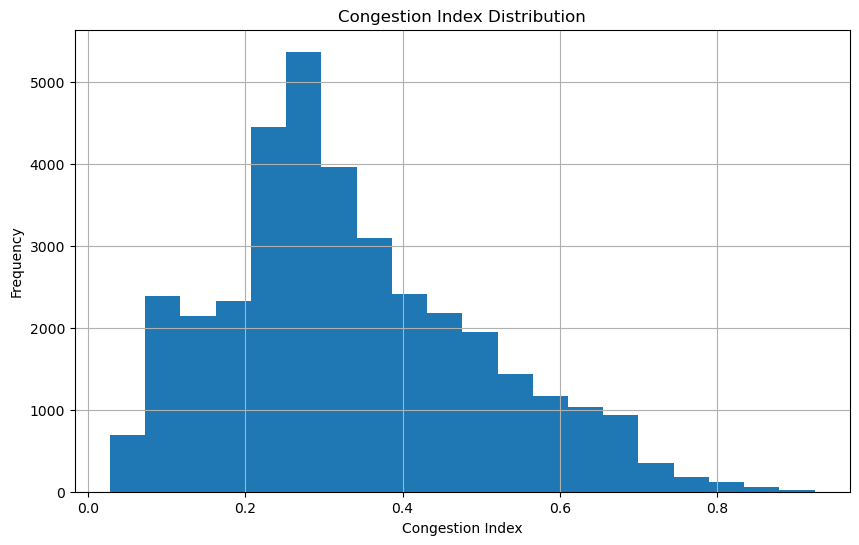

In [9]:
plt.figure(figsize=(10,6))

plt.hist(
    df['Congestion_Index'],
    bins=20
)

plt.xlabel("Congestion Index")
plt.ylabel("Frequency")

plt.title("Congestion Index Distribution")

plt.grid(True)

plt.show()